In [ ]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import interpolate
import itertools as it
import seaborn as sns
from matplotlib.lines import Line2D

C:\Users\andre\AppData\Local\Temp\ipykernel_28220\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
analysis = "DIRK_kinetic_analysis"

colors, colours = colourblind_palette("own")

#model = "cyclic_2021"
#model = "cyclic_2021_ODE"
#model = "new_PSI"
#model = "new_PSII"
#model = "new_b6f"
model = "with_dpsi"
#model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [3]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [4]:
y0 = get_stst_y0(m, pfd =70) # pfd = 1200

In [5]:
s = Simulator(m)

# General quick scan through parameters for P700 and dpsi

In [6]:
def careful_change_parameter(s, param, value, original_parameters): # When you change a parameter in s, the parameter in m is also changed. Therefore always reset all parameters to the original ones before changing a parameter
        s.update_parameters(original_parameters)  # Reset to original parameters
        s.update_parameter(param, value)  # Change the parameter to the new value

In [43]:
def change_and_plot(s, protocol, params_and_perturbations, compound, ax_kwargs, legend_loc, log = True, set_equal_startingpoint = False):
    pfd_illum = protocol[0][1]
    y0 = get_stst_y0(m, pfd =pfd_illum)

    original_parameters = {param: m.get_parameter(param) for param in list(params_and_perturbations.keys())}
    print(original_parameters)

    for param, value in original_parameters.items():

        fig, ax = plt.subplots(1,1,figsize=(6,3), sharex = True) # 6,4

        perturbed_param = params_and_perturbations[param]*value

        for i, value in enumerate(perturbed_param):

            s.initialise(y0)

            careful_change_parameter(s, param, value, original_parameters)

            try:
                c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)
            except Exception:
                print(f"Simulation of {param} = {value} failed")
                continue

            trace = c[compound] if compound != "dpsi" else 1e6*c[compound]

            if set_equal_startingpoint: trace -= trace[0]

            ax.plot(trace, label=f"{param} = {round(value,2)}", color=colors[i])
            
        label2 = Line2D([], [], color='none', label=f"{pfd_illum} µE")
        ax.add_artist(ax.legend(handles=[label2], loc="lower left", handlelength=0, handletextpad=0))
        
        shade_light(c, ax, max_alpha=0.15)
        ax.set(**ax_kwargs)
        if legend_loc:
            ax.legend(loc = legend_loc)
        else:
            ax.legend()

        plt.show()

    s.update_parameters(original_parameters)

In [52]:
pre_relax_time = 0.005 #0.005
pfd_illum = 300 #500
relax_time = 0.04 #0.03
relax_pfd = 0.01 # 0
post_relax_time = 0.005 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

legend_loc = "upper center"
params_and_perturbations = {"max_b6f": np.array([0.8, 1, 1.2]),
                             "kPCox": np.array([0.5, 1, 2]),
                             "pHstroma": np.array([0.997, 1, 1.003]),
                             "pKreg": np.array([0.95, 1, 1.05,])
                             }
#compound = "dpsi"
compound = "rel_P700+"
ax_kwargs = {"xlabel":"Time (ms)",
            "ylabel": "P700$^+$",
            #"ylabel": "$\Delta \psi$",
            "yscale": "log"
            }

{'max_b6f': 500, 'kPCox': 2500.0, 'pHstroma': 7.9, 'pKreg': 6.2}


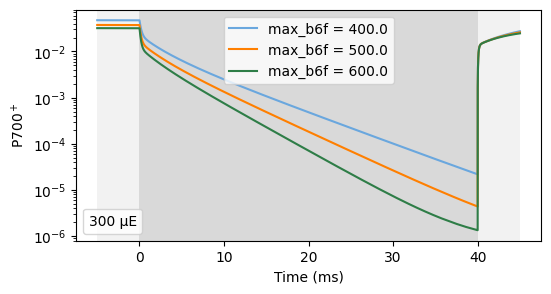

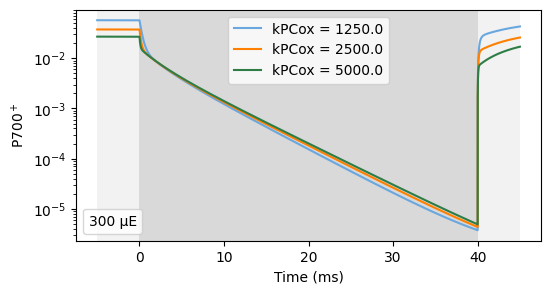

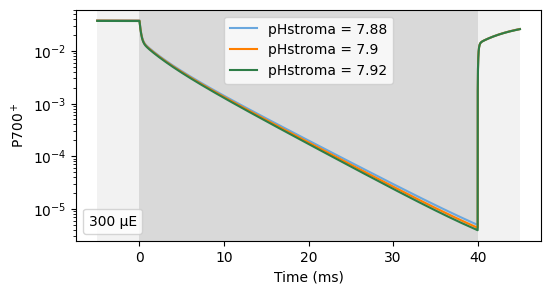

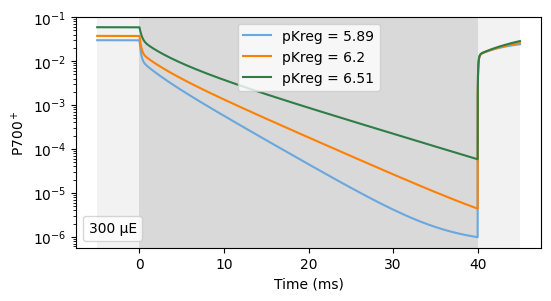

In [53]:
change_and_plot(s, protocol, params_and_perturbations, compound, ax_kwargs, legend_loc)

{'k_e_cbb_relaxation': 0.1, 'thioredoxin_tot': 1, 'k_fd_tr_reductase': 1, 'e_cbb_tot': 6, 'V9_base': 0.32}


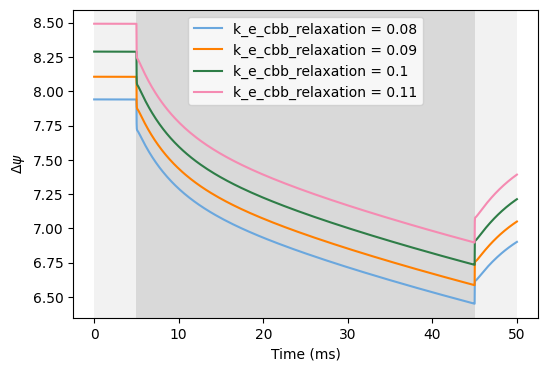

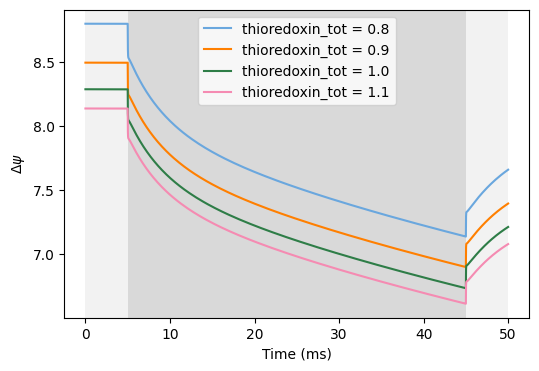

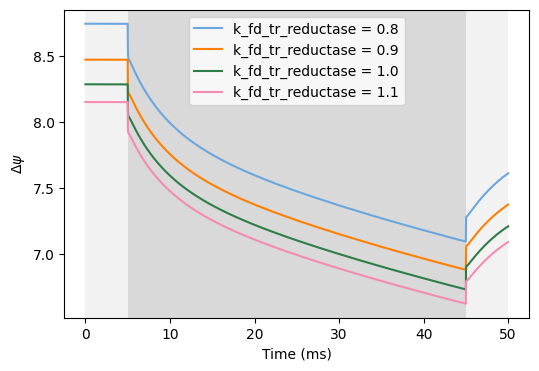

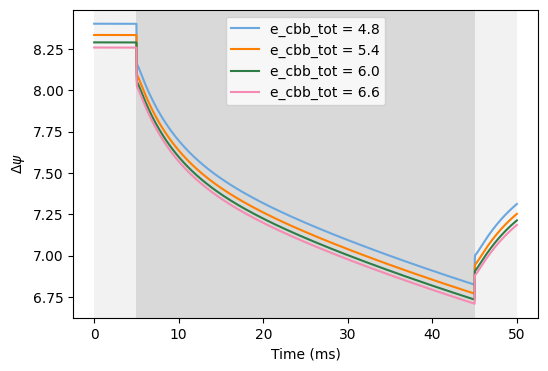

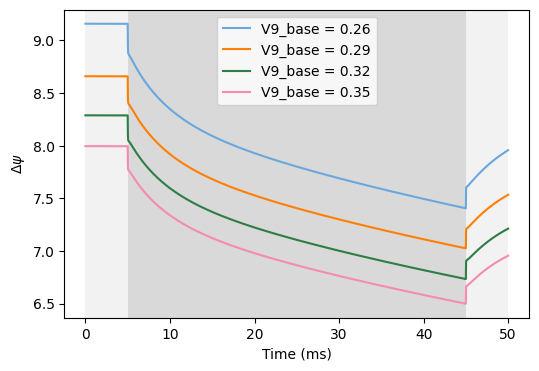

In [34]:
compound = "dpsi"
ax_kwargs = {"xlabel":"Time (ms)",
            "ylabel": "$\Delta \psi$",
            #"yscale": "log"
            }
params_and_perturbations = {"k_e_cbb_relaxation":np.array([0.8, 0.9, 1, 1.1,]),
                            "thioredoxin_tot":np.array([0.8, 0.9, 1, 1.1,]),
                            "k_fd_tr_reductase": np.array([0.8, 0.9, 1, 1.1,]),
                            "e_cbb_tot": np.array([0.8, 0.9, 1, 1.1,]),
                            "V9_base":np.array([0.8, 0.9, 1, 1.1,])}

change_and_plot(s, protocol, params_and_perturbations, compound, title, ax_kwargs, legend_loc)

{'n_ST': 2.0, 'KM_ST': 0.2}


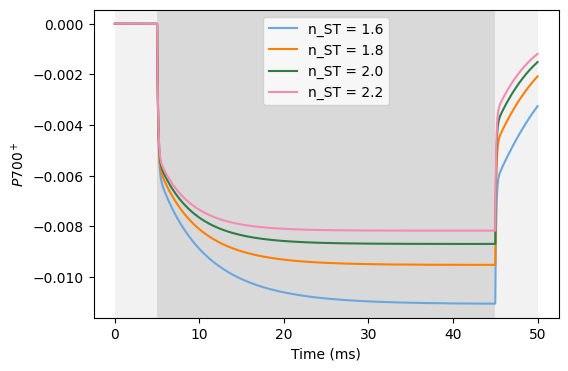

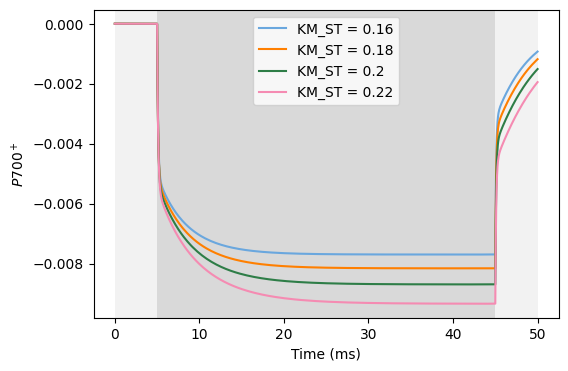

In [11]:
# compound = "dpsi"
compound = "rel_P700+"
ax_kwargs = {"xlabel":"Time (ms)",
            #"ylabel": "$\Delta \psi$",
            "ylabel": "$P700^+$",
            #"yscale": "log"
            }
params_and_perturbations = {"n_ST":np.array([0.8, 0.9, 1, 1.1,]),
                            "KM_ST":np.array([0.8, 0.9, 1, 1.1,])}

protocol = [[pre_relax_time, 100],
            [relax_time, relax_pfd],
            [post_relax_time, 100]
            ]

change_and_plot(s, protocol, params_and_perturbations, compound, "", ax_kwargs, legend_loc, set_equal_startingpoint = True)

{'T': 298.0}


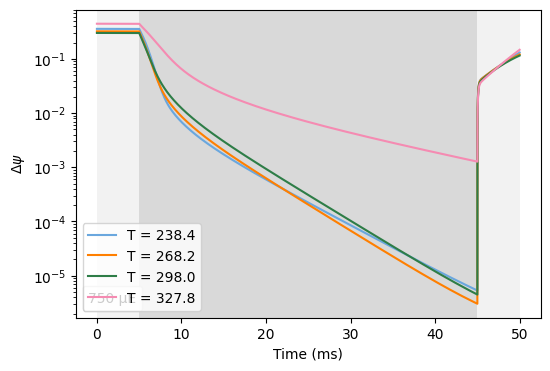

In [25]:
compound = "dpsi"
compound = "rel_P700+"
ax_kwargs = {"xlabel":"Time (ms)",
            "ylabel": "$\Delta \psi$",
            #"ylabel": "$P700^+$",
            "yscale": "log"
            }
params_and_perturbations = {"T":np.array([0.8, 0.9, 1, 1.1,])}

protocol = [[pre_relax_time, 750],
            [relax_time, relax_pfd],
            [post_relax_time, 750]
            ]

change_and_plot(s, protocol, params_and_perturbations, compound, "", ax_kwargs, legend_loc, set_equal_startingpoint = False)

{'kATPsynth': np.float64(22.0)}


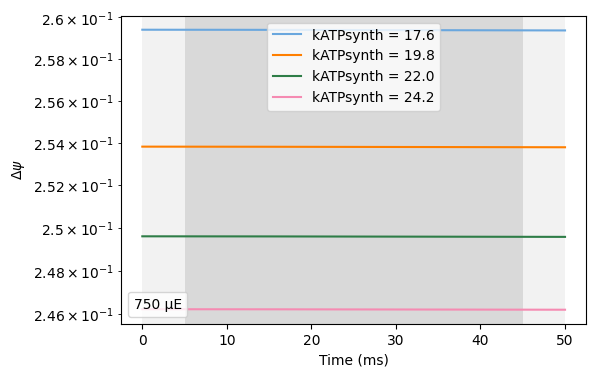

In [ ]:
compound = "dpsi" # also Q possible
#compound = "rel_P700+"
ax_kwargs = {"xlabel":"Time (ms)",
            "ylabel": "$\Delta \psi$",
            #"ylabel": "$P700^+$",
            "yscale": "log"
            }
params_and_perturbations = {"kATPsynth":np.array([0.8, 0.9, 1, 1.1,])}

protocol = [[pre_relax_time, 750],
            [relax_time, relax_pfd],
            [post_relax_time, 750]
            ]

change_and_plot(s, protocol, params_and_perturbations, compound, "", ax_kwargs, legend_loc, set_equal_startingpoint = False)

In [ ]:
# compound = "dpsi"
compound = "rel_P700+"
ax_kwargs = {"xlabel":"Time (ms)",
            #"ylabel": "$\Delta \psi$",
            "ylabel": "$P700^+$",
            #"yscale": "log"
            }
params_and_perturbations = {"n_ST":np.array([0.8, 0.9, 1, 1.1,]),
                            "KM_ST":np.array([0.8, 0.9, 1, 1.1,])}

protocol = [[pre_relax_time, 100],
            [relax_time, relax_pfd],
            [post_relax_time, 100]
            ]

change_and_plot(s, protocol, params_and_perturbations, compound, title, ax_kwargs, legend_loc, set_equal_startingpoint = True)

# nice plots: P700+ rereduction kinetics

In [6]:
max_b6f_normal = 500
kPCox_normal = 2500
kFdred_normal = 2.5e5
kcatFNR_normal = 500
kMehler_normal = 1
kcyc_normal = 1
pKreg_normal = 6.2
pHstroma_normal = 7.9
kATPsynth_normal = 20

In [ ]:
pfd_illum = 250 #500

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

[Text(0.5, 0, 'time (ms)'), Text(0, 0.5, 'P700$^+$')]

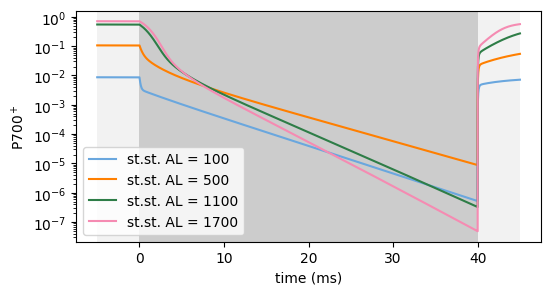

In [8]:
#plotting in log
cutoff = 1e-10

fig, ax = plt.subplots(figsize=(6, 3))

for i, pfd_illum in enumerate([100,500,1100,1700]):
    s.initialise(y0)

    protocol[0][1], protocol[2][1] = pfd_illum, pfd_illum # update protocol

    c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms= True) 

    for_plot = c["rel_P700+"]

    ax.plot(c.index, for_plot, label=f"st.st. AL = {pfd_illum}", color=colors[i])

shade_light(c, ax)
ax.legend()
ax.set_yscale("log")
ax.set(
    xlabel=("time (ms)"),
    ylabel=("P700$^+$"))
# ax.set_xlim(0.2, 0.5)
# ax.set_ylim(0.01221, 0.01223)

In [44]:
save_fig(fig, model, analysis,  f"log_of_DIRKs_pfd_dependent")

existing figure backed up to figures/latest_dev/kinetic_analysis/Z_backup_log_of_DIRKs_pfd_dependent.png
saved figure to figures/latest_dev/kinetic_analysis/log_of_DIRKs_pfd_dependent.png


[(0.005, 250), (0.045, 0), (0.049999999999999996, 250)]
[(0.005, 250), (0.045, 0), (0.049999999999999996, 250)]
[(0.005, 250), (0.045, 0), (0.049999999999999996, 250)]


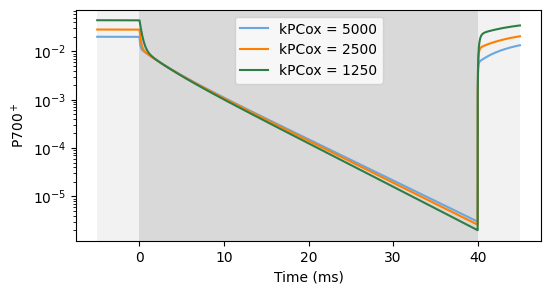

In [ ]:
#plotting inverse for hyperbolic part of the curve

pre_relax_time = 0.005 #0.005
pfd_illum = 250 #500
relax_time = 0.04 #0.03
relax_pfd = 0 
post_relax_time = 0.005 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

y0 = get_stst_y0(m, pfd =pfd_illum)
# s = Simulator(m)
# s.initialise(y0)

fig, ax = plt.subplots(1,1,figsize=(6, 3), sharex = True)

for i in range(0,1):
    for j in range(0,3):

        if i == 0: max_b6f = max_b6f_normal

        if j == 0: kPCox = kPCox_normal * 2
        if j == 1: kPCox = kPCox_normal 
        if j == 2: kPCox = kPCox_normal * 0.5

        s.initialise(y0)
        s.update_parameters({"kPCox": kPCox}) # reset to normal!
        s.initialise(y0)
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)

        #c.index = c.index * 1000 # conversion from s to ms.

        for_plot = c["rel_P700+"]

        ax.plot(c.index, for_plot, label=f"kPCox = {int(kPCox)}", color=colors[j])
        
shade_light(c, ax, max_alpha=0.15)

# ax.set_xlim(0, 30)

#ax.set(title = f"P700$^+$ from st.st. at AL = {pfd_illum}")
ax.legend(loc ="upper center")
ax.set(#ylim=(0, 0.15),
    xlabel=("Time (ms)"),
    ylabel=("P700$^+$"))
ax.set_yscale("log")
# ax[1].set_yscale("log")
# ax[2].set_yscale("log")
#ax[0][0].set_xlim(0.12, 0.35)
# ax.set_ylim(0.01221, 0.01223)

In [75]:
save_fig(fig, model, analysis, f"DIRK_P700_initial_drop_kPCox_AL{pfd_illum}")

saved figure to figures/latest_dev/kinetic_analysis/DIRK_P700_initial_drop_kPCox_AL250.png


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[(0.005, 300), (0.045, 0.01), (0.049999999999999996, 300)]


[Text(0.5, 0, 'Time (ms)')]

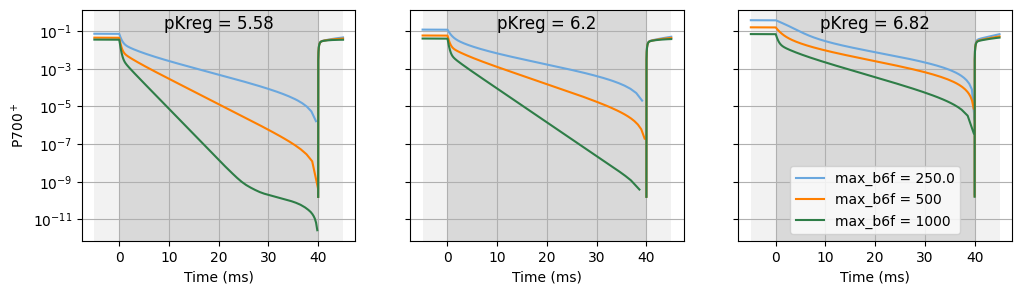

In [ ]:
#plotting in log
cutoff = 1e-14

pre_relax_time = 0.005 #0.005
pfd_illum = 300 #500
relax_time = 0.04 #0.03
relax_pfd = 0.01 # 0
post_relax_time = 0.005 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

y0 = get_stst_y0(m, pfd =pfd_illum) 
# s = Simulator(m)
# s.initialise(y0)

fig, ax = plt.subplots(1,3,figsize=(12, 3), sharey = True, sharex = True)


for i in range(0,3):
    for j in range(0,3):
        if i == 0: max_b6f = max_b6f_normal * 0.5
        if i == 1: max_b6f = max_b6f_normal 
        if i == 2: max_b6f = max_b6f_normal * 2

        if j == 0: pKreg = pKreg_normal * 0.9
        if j == 1: pKreg = pKreg_normal * 1
        if j == 2: pKreg = pKreg_normal * 1.1

        s.initialise(y0)
        s.update_parameters({"max_b6f": max_b6f, "pKreg": pKreg}) # reset to normal!
        s.initialise(y0)
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)

        for_plot = c["rel_P700+"] - min(c["rel_P700+"])     #0.0005
        for_plot[for_plot<=cutoff]=np.nan

        ax[j].plot(c.index, for_plot, label=f"max_b6f = {max_b6f}", color=colors[i])
        ax[j].set_title(f"pKreg = {round(pKreg, 2)}", x=0.5, y=0.88)# x=0.5 (center), y=0.85 (near top)
        ax[j].grid()

shade_light(c, ax, max_alpha=0.15)
ax[2].legend()

ax[0].set_yscale("log")

ax[0].set(
    xlabel=("Time (ms)"),
    ylabel=("P700$^+$"))
ax[1].set(
    xlabel=("Time (ms)"))
ax[2].set(
    xlabel=("Time (ms)"))

#fig.suptitle(f"pfd = {pfd_illum}")
# ax[1].set_yscale("log")
# ax[2].set_yscale("log")
# ax.set_ylim(0.01221, 0.01223)

In [73]:
save_fig(fig, model, analysis, f"DIRK_P700_initial_main_exponential")

existing figure backed up to figures/latest_dev/kinetic_analysis/Z_backup_DIRK_P700_initial_main_exponential.png
saved figure to figures/latest_dev/kinetic_analysis/DIRK_P700_initial_main_exponential.png


[Text(0.5, 0, 'Time (ms)')]

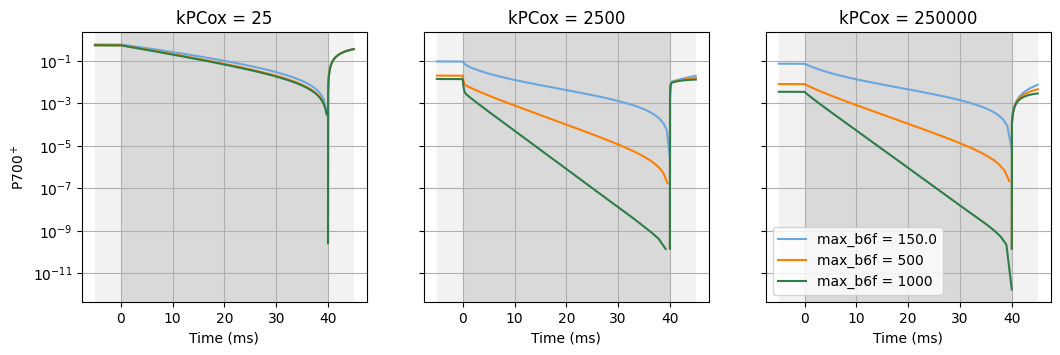

In [22]:
#plotting in log
cutoff = 1e-14

pre_relax_time = 0.005 #0.005
pfd_illum = 200 #500
relax_time = 0.04 #0.03
relax_pfd = 0.01 # 0
post_relax_time = 0.005 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

y0 = get_stst_y0(m, pfd =pfd_illum)
# s = Simulator(m)
# s.initialise(y0)

fig, ax = plt.subplots(1,3,figsize=(12.5, 3.5), sharey = True, sharex = True)

for i in range(0,3):
    for j in range(0,3):
        if i == 0: max_b6f = max_b6f_normal * 0.3
        if i == 1: max_b6f = max_b6f_normal 
        if i == 2: max_b6f = max_b6f_normal * 2

        if j == 0: kPCox = kPCox_normal * 0.01
        if j == 1: kPCox = kPCox_normal
        if j == 2: kPCox = kPCox_normal * 100

        s.initialise(y0)
        s.update_parameters({"max_b6f": max_b6f, "kPCox": kPCox}) # reset to normal!
        s.initialise(y0)
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)

        for_plot = c["rel_P700+"] - min(c["rel_P700+"])     #0.0005
        for_plot[for_plot<=cutoff]=np.nan

        ax[j].plot(c.index, for_plot, label=f"max_b6f = {max_b6f}", color=colors[i])
        ax[j].set(title = f"kPCox = {int(kPCox)}")
        ax[j].grid()

shade_light(c, ax, max_alpha=0.15)
ax[2].legend()

ax[0].set_yscale("log")

ax[0].set(
    xlabel=("Time (ms)"),
    ylabel=("P700$^+$"))
ax[1].set(
    xlabel=("Time (ms)"))
ax[2].set(
    xlabel=("Time (ms)"))

#fig.suptitle(f"pfd = {pfd_illum}")
# ax[1].set_yscale("log")
# ax[2].set_yscale("log")
# ax.set_ylim(0.01221, 0.01223)

In [23]:
save_fig(fig, model, analysis, f"DIRK_P700_kPCox_limiting_if_very_low")

saved figure to figures/with_dpsi/DIRK_kinetic_analysis/DIRK_P700_kPCox_limiting_if_very_low.png


3it [00:00,  5.29it/s]
3it [00:00,  4.53it/s]
3it [00:00,  5.16it/s]


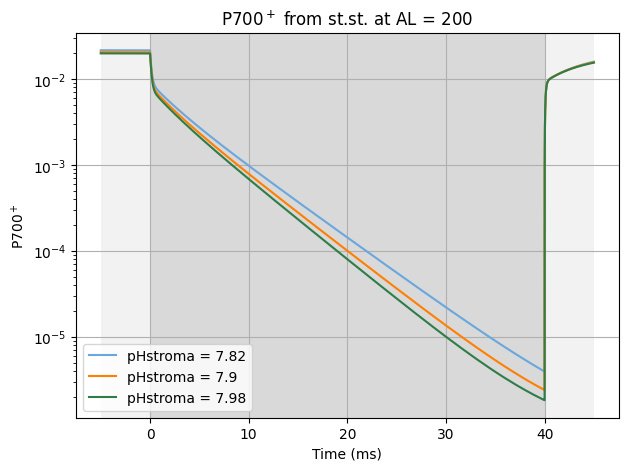

In [ ]:
#plotting logarithmic plot

pre_relax_time = 0.005 #0.005
pfd_illum = 200 #500
relax_time = 0.04 #0.03
relax_pfd = 0.01 # 0
post_relax_time = 0.005 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

y0 = get_stst_y0(m, pfd =pfd_illum)
# s = Simulator(m)
# s.initialise(y0)

fig, ax = plt.subplots(1,1,figsize=(7, 5), sharex = True)


for i in range(0,1):
    for j in range(0,3):

        if i == 0: max_b6f = max_b6f_normal

        if j == 0: pHstroma = pHstroma_normal * 0.99
        if j == 1: pHstroma = pHstroma_normal 
        if j == 2: pHstroma = pHstroma_normal * 1.01

        s.initialise(y0)
        s.update_parameters({"pHstroma": pHstroma}) # reset to normal!
        s.initialise(y0)
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)

        #c.index = c.index * 1000 # conversion from s to ms.

        for_plot = c["rel_P700+"]

        ax.plot(c.index, for_plot, label=f"pHstroma = {round(pHstroma,2)}", color=colors[j])
        
shade_light(c, ax, max_alpha=0.15)

# ax.set_xlim(0, 30)

ax.set(title = f"P700$^+$ from st.st. at AL = {pfd_illum}")
ax.grid()
ax.legend(loc ="lower left")
ax.set(#ylim=(0, 0.15),
    xlabel=("Time (ms)"),
    ylabel=("P700$^+$"))
# ax[0][0].set_yscale("log")
ax.set_yscale("log")
# ax[2].set_yscale("log")
#ax[0][0].set_xlim(0.12, 0.35)
# ax.set_ylim(0.01221, 0.01223)

3it [00:01,  1.94it/s]
3it [00:01,  1.55it/s]
3it [00:01,  1.67it/s]


[Text(0.5, 0, 'Time (ms)'), Text(0, 0.5, '1 / P700$^+$')]

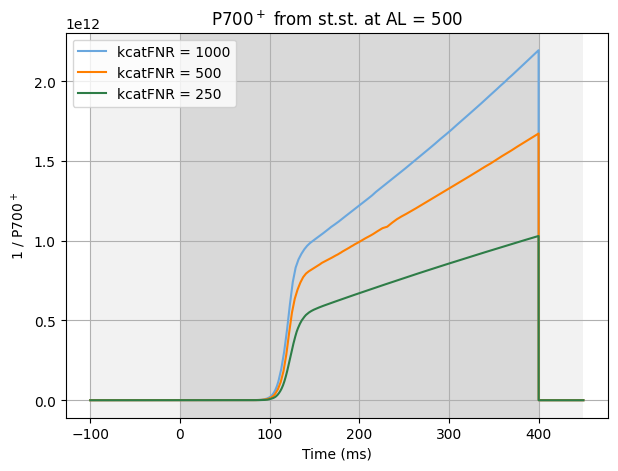

In [ ]:
#plotting inverse for hyperbolic part of the curve

pre_relax_time = 0.1 #0.005
pfd_illum = 500 #500
relax_time = 0.4 #0.03
relax_pfd = 0.0 # 0 # <- not 0.001 or something, this breaks it
post_relax_time = 0.05 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

y0 = get_stst_y0(m, pfd =pfd_illum)
# s = Simulator(m)
# s.initialise(y0)

fig, ax = plt.subplots(1,1,figsize=(7, 5), sharex = True)

for i in range(0,1):
    for j in range(0,3):

        if i == 0: max_b6f = max_b6f_normal

        if j == 0: kcatFNR = kcatFNR_normal * 2
        if j == 1: kcatFNR = kcatFNR_normal 
        if j == 2: kcatFNR = kcatFNR_normal * 0.5

        s.initialise(y0)
        s.update_parameters({"kcatFNR": kcatFNR, "max_b6f": max_b6f}) # reset to normal!
        s.initialise(y0)
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)

        #c.index = c.index * 1000 # conversion from s to ms.

        for_plot = c["rel_P700+"]
        for_plot = 1/for_plot

        ax.plot(c.index, for_plot, label=f"kcatFNR = {int(kcatFNR)}", color=colors[j])
        
shade_light(c, ax, max_alpha=0.15)

# ax.set_xlim(0, 30)

ax.set(title = f"P700$^+$ from st.st. at AL = {pfd_illum}")
ax.grid()
ax.legend(loc ="upper left")
ax.set(#ylim=(0, 0.15),
    xlabel=("Time (ms)"),
    ylabel=("1 / P700$^+$"))
# ax[0][0].set_yscale("log")
# ax[1].set_yscale("log")
# ax[2].set_yscale("log")
#ax[0][0].set_xlim(0.12, 0.35)
# ax.set_ylim(0.01221, 0.01223)

In [49]:
save_fig(fig, model, analysis, f"hyperbolic_decay_extended_DIRK")

saved figure to figures/latest_dev/kinetic_analysis/hyperbolic_decay_extended_DIRK.png


# nice plots: Delta psi!

[Text(0.5, 0, 'time (ms)'), Text(0, 0.5, '$\\Delta \\psi$'), None]

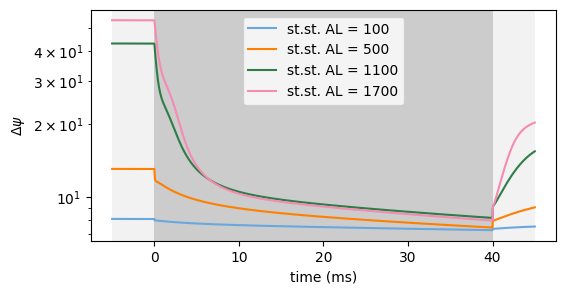

In [20]:
#plotting in log
cutoff = 1e-10

fig, ax = plt.subplots(figsize=(6, 3))

for i, pfd_illum in enumerate([100,500,1100,1700]):
    s.initialise(y0)

    protocol[0][1], protocol[2][1] = pfd_illum, pfd_illum # update protocol

    c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms= True) 

    for_plot = c["dpsi"]*1e6

    ax.plot(c.index, for_plot, label=f"st.st. AL = {pfd_illum}", color=colors[i])

shade_light(c, ax)
ax.legend()
ax.set(
    xlabel= "time (ms)",
    ylabel="$\Delta \psi$",
    yscale = "log"
    )

In [ ]:
pre_relax_time = 0.005 #0.005
pfd_illum = 750 #500
relax_time = 0.04 #0.03
relax_pfd = 0.01 # 0
post_relax_time = 0.005 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

y0 = get_stst_y0(m, pfd =pfd_illum)

s.initialise(y0)
c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)

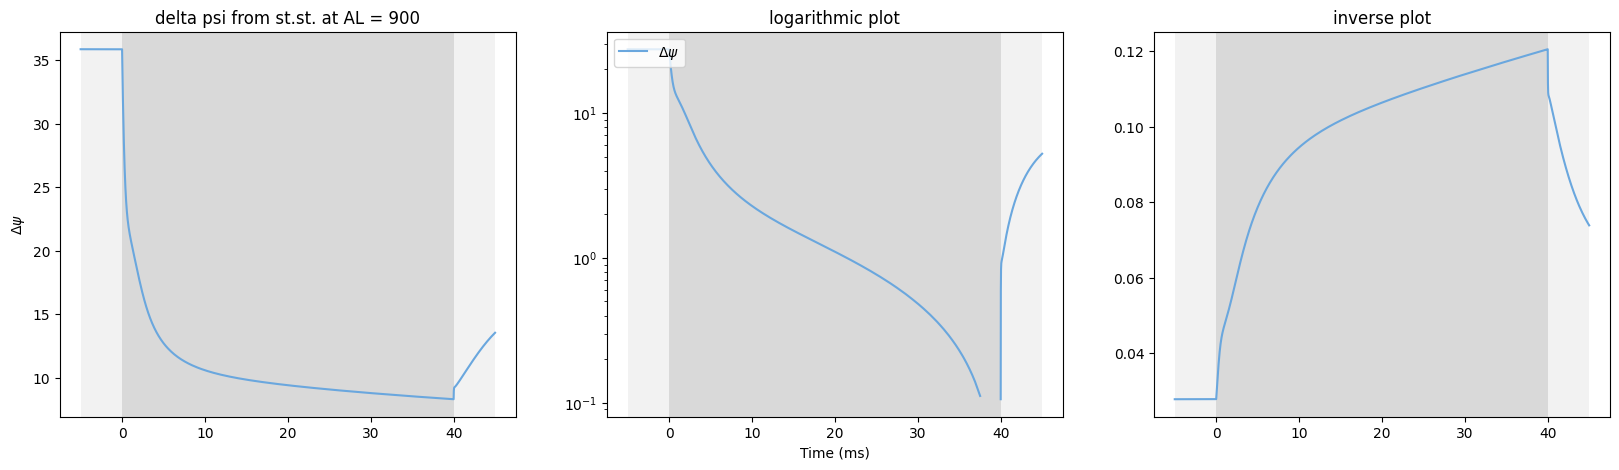

In [16]:
# plot log 
const = 0 #log plotting #asymptotic value for PFD = 900

delta_psi = 1e6*c["dpsi"]
psi4logplot = delta_psi - min(delta_psi) + const
psi4logplot[psi4logplot <= 1e-1] = np.nan

psi4invplot = 1/(delta_psi+ const)
#psi4invplot[psi4invplot <= 1e-1] = np.nan

fig, ax = plt.subplots(1,3, figsize = (20,5), sharex = True)
ax[1].set(#ylim=(0, 0.15),
    xlabel=("Time (ms)"))
ax[0].set(ylabel=(r"$\Delta\psi$"))
ax[0].set(title = f"delta psi from st.st. at AL = {pfd_illum}")
ax[1].set(title="logarithmic plot")
ax[2].set(title="inverse plot")

ax[0].plot(c.index, delta_psi, color = colors[0])

ax[1].plot(c.index, psi4logplot, label=r"$\Delta\psi$", color=colors[0])

ax[1].legend(loc ="upper left")
ax[1].set_yscale("log")

ax[2].plot(c.index, psi4invplot, label="Light", color=colors[0])


shade_light(c, ax, max_alpha=0.15)


3it [00:01,  2.53it/s]
3it [00:01,  2.72it/s]
3it [00:01,  2.98it/s]
3it [00:01,  2.85it/s]
3it [00:01,  2.95it/s]
3it [00:01,  2.78it/s]
3it [00:01,  2.65it/s]
3it [00:01,  2.97it/s]
3it [00:01,  2.81it/s]


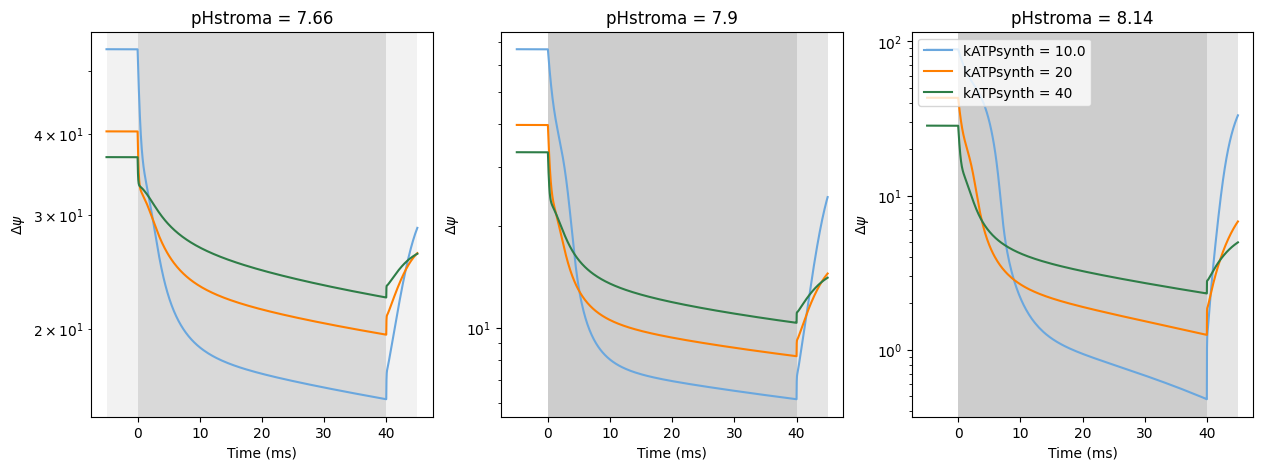

In [ ]:
#plotting inverse for hyperbolic part of the curve

pre_relax_time = 0.005 #0.005
pfd_illum = 1000 #500
relax_time = 0.04 #0.03
relax_pfd = 0.01 # 0
post_relax_time = 0.005 # 0.005

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

y0 = get_stst_y0(m, pfd =pfd_illum)
# s = Simulator(m)
# s.initialise(y0)

fig, ax = plt.subplots(1,3,figsize=(15, 5), sharex = True, sharey = False)

for i in range(0,3):
    for j in range(0,3):

        if i == 0: kATPsynth = kATPsynth_normal * 0.5
        if i == 1: kATPsynth = kATPsynth_normal
        if i == 2: kATPsynth = kATPsynth_normal * 2

        if j == 0: pHstroma = pHstroma_normal * 0.97
        if j == 1: pHstroma = pHstroma_normal 
        if j == 2: pHstroma = pHstroma_normal * 1.03

        s.initialise(y0)
        s.update_parameters({"kATPsynth": kATPsynth, "pHstroma": pHstroma}) # reset to normal!
        s.initialise(y0)
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = True, output_in_ms = True)

        #c.index = c.index * 1000 # conversion from s to ms.

        delta_psi = c["dpsi"]*1e6
        psi4plot = delta_psi # - min(delta_psi)
        psi4plot[psi4plot <= 1e-2] = np.nan

        ax[j].plot(c.index, psi4plot, label=f"kATPsynth = {round(kATPsynth,2)}", color=colors[i])
        ax[j].set(title = f"pHstroma = {round(pHstroma,2)}",
                  xlabel=("Time (ms)"),
                  ylabel=(r"$\Delta\psi$"),
                  yscale=("log")
                  )
        
shade_light(c, ax, max_alpha=0.15)


ax[2].legend(loc ="upper left")
# ax[0][0].set_yscale("log")
# ax[2].set_yscale("log")
#ax[0][0].set_xlim(0.12, 0.35)
# ax.set_ylim(0.01221, 0.01223)